# Access the analysis ready satellite earth radiation budget data

This notebook provides an example of how to open the satellite-earth-radiation-budget Zarr store using xarray.
You will need to insert your CDS API key where indicated in the following code cell (available on [your profile page](https://cds.climate.copernicus.eu/profile)).
For more information on using the Data Store Analysis Ready Datasets, please see the [user documentation pages](https://cds.climate.copernicus.eu/datasets/how-to-use-the-dss-arco-dataset).

In [1]:
import os
cdsapi_key = "<INSERT-CDS-API-KEY-HERE>"

# The following attempts to find the CDSAPI key in your environment.
if cdsapi_key == "<INSERT-CDS-API-KEY-HERE>":
    cdsapi_key = None
if cdsapi_key is None:
    cdsapi_key = os.getenv("CDSAPI_KEY")
if cdsapi_key is None and os.path.exists(os.path.expanduser("~/.cdsapirc")):
    with open(os.path.expanduser("~/.cdsapirc"), "r") as f:
        for line in f:
            if line.startswith("key:"):
                cdsapi_key = line.split(":")[1].strip()
                break
if cdsapi_key is None:
    raise ValueError("CDSAPI key not found. Please set the CDSAPI_KEY environment variable or create a ~/.cdsapirc file.")


## Plug and play access

The code below provides a simple plug and play example of how to use the Zarr Store for light-weight access.

This dataset contains **14 sub-items** covering different instruments (CERES, HIRS) and temporal resolutions (daily, monthly). The sub-item identifiers follow the pattern `{tcdr|icdr}-{instrument}-{daily|monthly}`. The example below uses the CERES TCDR monthly data.

In [2]:
import xarray as xr

# Geo-chunked CERES TCDR monthly data
geochunked_ceres_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/ceres-tcdr-monthly/geoChunked.zarr"

# Time-chunked CERES TCDR monthly data
timechunked_ceres_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/ceres-tcdr-monthly/timeChunked.zarr"

# Geo-chunked HIRS TCDR monthly data
geochunked_hirs_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/hirs-tcdr-monthly/geoChunked.zarr"

# Time-chunked HIRS TCDR monthly data
timechunked_hirs_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/hirs-tcdr-monthly/timeChunked.zarr"

# Geo-chunked HIRS ICDR daily data
geochunked_hirs_icdr_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/hirs-icdr-daily/geoChunked.zarr"

# Time-chunked HIRS ICDR daily data
timechunked_hirs_icdr_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/hirs-icdr-daily/timeChunked.zarr"


# Open the zarr store with xarray, users must insert their API key where indicated.
ds = xr.open_zarr(
    geochunked_ceres_tcdr_monthly_url,
    consolidated=True,
     storage_options = {
        "headers": {"Authorization": f"Bearer {cdsapi_key}"}
    }
)
 
# Inspect the variables
ds

<xarray.Dataset> Size: 242MB
Dimensions:         (time: 311, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2000-03-01 ... 2026-01-01
  * latitude        (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    solar_mon       (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>
    toa_lw_all_mon  (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>
    toa_sw_all_mon  (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>

Extract a point and plot a time-series of top-of-atmosphere shortwave radiation using earthkit-plots.

/var/folders/l2/529q7bzs665bnrn7_wjx1nsr0000gn/T/ipykernel_79581/2320519952.py:9: UserWarning: TimeSeries is an experimental new feature in earthkit-plots. We welcome feedback and bug reports on GitHub issues: https://github.com/ecmwf/earthkit-plots/issues
  chart = ekp.TimeSeries()
/Users/edwardcomyn-platt/Work/Git_Repositories/ecmwf-projects/dss-jupyterhub-notebooks/dss-notebooks/.venv/lib/python3.12/site-packages/earthkit/plots/components/subplots.py:1213: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  self.ax.legend(*args, **kwargs)


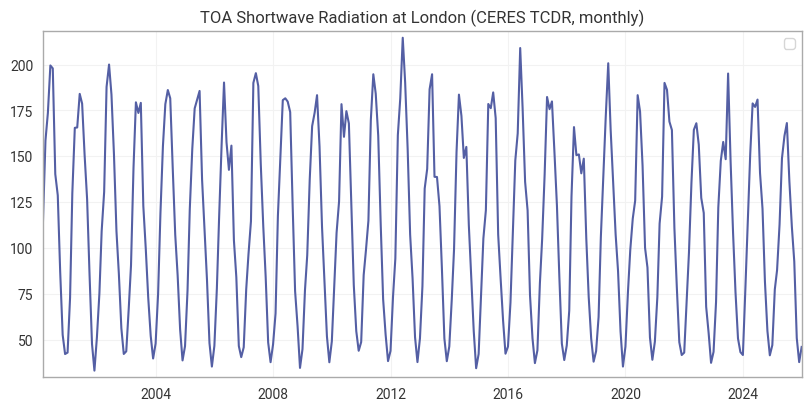

In [3]:
from earthkit import plots as ekp

# Select variable to plot
variable_name = "toa_sw_all_mon"
plot_data = ds[variable_name].sel(
    latitude=51.5, longitude=-0.1, method="nearest"
)

chart = ekp.TimeSeries()

chart.line(plot_data)

chart.title("TOA Shortwave Radiation at London (CERES TCDR, monthly)")
chart.legend()

chart.show()

## Advanced usage

If your workflow requires access to larger amounts of data, it is recommended that you include a retry mechanism.
This is not provided in the current default zarr engine for xarray, instead we can define a custom "`store`" which is
used when connecting to the remote zarr data.

In [4]:
!pip install -q obstore
import xarray as xr
from obstore.store import HTTPStore
from zarr.storage import ObjectStore

# Geo-chunked CERES TCDR monthly data
geochunked_ceres_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/ceres-tcdr-monthly/geoChunked.zarr"

# Time-chunked CERES TCDR monthly data
timechunked_ceres_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/ceres-tcdr-monthly/timeChunked.zarr"

# Geo-chunked HIRS TCDR monthly data
geochunked_hirs_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/hirs-tcdr-monthly/geoChunked.zarr"

# Time-chunked HIRS TCDR monthly data
timechunked_hirs_tcdr_monthly_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/hirs-tcdr-monthly/timeChunked.zarr"

# Geo-chunked HIRS ICDR daily data
geochunked_hirs_icdr_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-geo-054/arco/satellite_earth_radiation_budget/hirs-icdr-daily/geoChunked.zarr"

# Time-chunked HIRS ICDR daily data
timechunked_hirs_icdr_daily_url = "https://arco.datastores.ecmwf.int/cadl-arco-time-054/arco/satellite_earth_radiation_budget/hirs-icdr-daily/timeChunked.zarr"


# Use obstore's HTTPStore to create a store with retry configuration,
# and then wrap it in a zarr ObjectStore to read with xarray.
# See https://github.com/developmentseed/obstore/blob/main/obstore/python/obstore/_store/_retry.pyi
# for more details on the retry configuration options.
http_store = HTTPStore(
    geochunked_ceres_tcdr_monthly_url,
    client_options={
        "default_headers": {"Authorization": f"Bearer {cdsapi_key}"},
    },
)
store = ObjectStore(http_store, read_only=True)
ds = xr.open_zarr(store)
ds

<xarray.Dataset> Size: 242MB
Dimensions:         (time: 311, latitude: 180, longitude: 360)
Coordinates:
  * time            (time) datetime64[ns] 2kB 2000-03-01 ... 2026-01-01
  * latitude        (latitude) float32 720B -89.5 -88.5 -87.5 ... 87.5 88.5 89.5
  * longitude       (longitude) float32 1kB -179.5 -178.5 -177.5 ... 178.5 179.5
Data variables:
    solar_mon       (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>
    toa_lw_all_mon  (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>
    toa_sw_all_mon  (time, latitude, longitude) float32 81MB dask.array<chunksize=(64, 128, 128), meta=np.ndarray>

The result is the same as the previous example, this just provides a more robust connection, preventing your
workflow crashing due to temporary network issues.